In [9]:
import scipy.sparse as sp
import matplotlib.pyplot as plt
from pathlib import Path
import pickle
import numpy as np
import networkx as nx
from collections import defaultdict, Counter
import pandas as pd
import re

data_dir = Path("../data/raw/gossipcop")   # adjust if needed
pol_map_path = data_dir / "gos_id_twitter_mapping.pkl"
profile_npz = data_dir / "new_profile_feature.npz"   # adjust name/location if needed

In [2]:
# load mapping
with open(pol_map_path, "rb") as f:
    node_to_label = pickle.load(f)

# separate news labels and candidate user labels
news_labels = [v for v in node_to_label.values() if isinstance(v, str) and v.startswith("gossipcop")]
user_labels_all = [v for v in node_to_label.values() if not (isinstance(v, str) and v.startswith("gossipcop"))]

print("Total node entries:", len(node_to_label))
print("News-label examples (first 10):", news_labels[:10])
print("Total candidate user-label entries (including duplicates):", len(user_labels_all))

# Are they numeric strings? which are not?
non_numeric = [v for v in user_labels_all if not (isinstance(v, str) and v.isdigit())]
numeric = [v for v in user_labels_all if isinstance(v, str) and v.isdigit()]

print("Numeric-like user labels:", len(numeric))
print("Non-numeric user labels (sample up to 10):", non_numeric[:10])

# uniqueness and multiplicity
unique_numeric = set(numeric)
print("Unique numeric user labels:", len(unique_numeric))
cnts = Counter(numeric)
most_common = cnts.most_common(10)
print("Top 10 most common user-labels (label, occurrences):", most_common)

# numeric ranges & size info (if any numeric exist)
if numeric:
    nums = np.array([int(x) for x in list(unique_numeric)])
    print("Min numeric label:", nums.min(), "Max:", nums.max())
    print("Example numeric label lengths (digits):", [len(x) for x in list(unique_numeric)[:5]])

# compare to profile features if present
if profile_npz.exists():
    try:
        X = sp.load_npz(profile_npz)
        n_rows = X.shape[0]
        print("Loaded profile features shape:", X.shape)
        print("Unique numeric user labels vs profile rows: unique_user_count =", len(unique_numeric), ", profile rows =", n_rows)
    except Exception as e:
        print("Could not load profile npz:", e)
else:
    print("Profile feature file not found at", profile_npz)

Total node entries: 314262
News-label examples (first 10): ['gossipcop-943234', 'gossipcop-905156', 'gossipcop-924455', 'gossipcop-941695', 'gossipcop-914354', 'gossipcop-919225', 'gossipcop-850093', 'gossipcop-862425', 'gossipcop-869138', 'gossipcop-846571']
Total candidate user-label entries (including duplicates): 308798
Numeric-like user labels: 308798
Non-numeric user labels (sample up to 10): []
Unique numeric user labels: 75914
Top 10 most common user-labels (label, occurrences): [('2530389144', 10817), ('25701904', 3767), ('2471499625', 3406), ('2858595360', 2465), ('20587567', 2435), ('10409622', 2185), ('600811002', 2095), ('840524255024492544', 1839), ('844966877075927040', 1814), ('4889604194', 1811)]
Min numeric label: 8709 Max: 1070024763081351168
Example numeric label lengths (digits): [10, 9, 18, 10, 8]
Profile feature file not found at ..\data\raw\new_profile_feature.npz


In [3]:
def load_news_list(path: Path):
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        return [ln.strip() for ln in f if ln.strip()]

def aggregate_user_shares_by_newslist(pol_map_path: Path, graph_path: Path, data_root: Path):
    """
    Correctly aggregate fake/true share counts per Twitter user by:
      - mapping news label string -> index in pol_news_list.txt
      - using that index to look up graph_labels.npy
      - using A.txt graph to find users connected to each news node
    Returns: dataframe with twitter_id, fake_count, true_count, total, fake_ratio
    """
    data_root = Path(data_root)
    # load files
    with open(pol_map_path, "rb") as f:
        node_to_label = pickle.load(f)   # node index -> label (e.g., "politifact4190" or "14200465")
    edges = np.loadtxt(graph_path, delimiter=",", dtype=int)
    G = nx.Graph()
    G.add_edges_from(edges)

    p = data_root / "gos_news_list.txt"
    pol_news = load_news_list(p)

    path = data_dir / "graph_labels.npy"
    graph_labels = np.load(path)
    # Build quick lookup: label string -> index in pol_news list
    news_label_to_index = {lbl: idx for idx, lbl in enumerate(pol_news)}

    user_stats = defaultdict(lambda: {"fake": 0, "true": 0})
    processed_news = 0
    skipped_no_match = 0
    skipped_out_of_range = 0

    # iterate over every node that looks like a news label
    for node_idx, label_str in node_to_label.items():
        # detect news node: label is a string that contains "politifact" (your mapping uses 'politifact####')
        if not (isinstance(label_str, str) and label_str.startswith("gossipcop")):
            continue

        # find index in pol_news (preferred exact match)
        if label_str in news_label_to_index:
            news_idx = news_label_to_index[label_str]
        else:
            # fallback: try to match by numeric suffix (digits) or substring
            digits = re.findall(r"\d+", label_str)
            found = False
            if digits:
                d = digits[-1]
                # try to find any pol_news entry that contains that digits substring
                for i, entry in enumerate(pol_news):
                    if d in entry:
                        news_idx = i
                        found = True
                        break
            if not found:
                skipped_no_match += 1
                continue

        # now get label value from graph_labels
        if news_idx < 0 or news_idx >= len(graph_labels):
            skipped_out_of_range += 1
            continue

        label_value = int(graph_labels[news_idx])   # 0 or 1
        processed_news += 1

        # neighbors in the graph are nodes connected to this news node (users)
        neighbors = list(G.neighbors(node_idx))
        for nbr in neighbors:
            user_label = node_to_label.get(nbr)
            # skip if neighbor is also a news node (rare) or missing
            if user_label is None or (isinstance(user_label, str) and user_label.startswith("politifact")):
                continue
            tw_key = str(user_label)
            if label_value == 0:
                user_stats[tw_key]["fake"] += 1
            else:
                user_stats[tw_key]["true"] += 1

    # build DataFrame
    df = pd.DataFrame([
        {"twitter_id": uid, "fake_count": v["fake"], "true_count": v["true"]}
        for uid, v in user_stats.items()
    ])
    if df.empty:
        print("No user data collected.")
        print("Processed news:", processed_news, "skipped_no_match:", skipped_no_match, "skipped_out_of_range:", skipped_out_of_range)
        return df

    df["total"] = df["fake_count"] + df["true_count"]
    df["fake_ratio"] = df["fake_count"] / df["total"].replace(0, np.nan)

    # reporting
    print(f"Processed news nodes: {processed_news}")
    print(f"Skipped (no label match in gos_news): {skipped_no_match}")
    print(f"Skipped (index out of range for graph_labels): {skipped_out_of_range}")
    print(f"Unique twitter users found: {len(df)}")

    return df

data_root = Path("../data/raw")         # your data root
pol_map_path = data_root / "gos_id_twitter_mapping.pkl"
graph_path = data_root / "gossipcop" / "A.txt"   # adjust to politifact A.txt location

df_users = aggregate_user_shares_by_newslist(pol_map_path, graph_path, data_root)

Processed news nodes: 5464
Skipped (no label match in gos_news): 0
Skipped (index out of range for graph_labels): 0
Unique twitter users found: 32670


In [4]:
top_news_sharers = df_users.sort_values("total", ascending=False).head(20)

print("Top 10 news sharers (independent of truth/fake):")
for i, row in top_news_sharers.iterrows():
    print(f"Twitter ID: {row['twitter_id']}, Total shares: {row['total']}, "
          f"Fake: {row['fake_count']}, True: {row['true_count']}, "
          f"Fake ratio: {row['fake_ratio']:.2f}")

Top 10 news sharers (independent of truth/fake):
Twitter ID: 2530389144, Total shares: 10817, Fake: 10653, True: 164, Fake ratio: 0.98
Twitter ID: 25701904, Total shares: 3767, Fake: 0, True: 3767, Fake ratio: 0.00
Twitter ID: 2471499625, Total shares: 3406, Fake: 3343, True: 63, Fake ratio: 0.98
Twitter ID: 2858595360, Total shares: 2465, Fake: 2401, True: 64, Fake ratio: 0.97
Twitter ID: 20587567, Total shares: 2435, Fake: 2388, True: 47, Fake ratio: 0.98
Twitter ID: 10409622, Total shares: 2185, Fake: 2146, True: 39, Fake ratio: 0.98
Twitter ID: 600811002, Total shares: 2095, Fake: 2062, True: 33, Fake ratio: 0.98
Twitter ID: 840524255024492544, Total shares: 1839, Fake: 1798, True: 41, Fake ratio: 0.98
Twitter ID: 844966877075927040, Total shares: 1814, Fake: 1775, True: 39, Fake ratio: 0.98
Twitter ID: 4889604194, Total shares: 1811, Fake: 1768, True: 43, Fake ratio: 0.98
Twitter ID: 844978796339986433, Total shares: 1808, Fake: 1768, True: 40, Fake ratio: 0.98
Twitter ID: 8397430

### Notes Users
Users often tend to only appear once, retweeting either true or false news once, but obviously there are exceptions as shown above, it may be noted that its not clear to discern from someones profile whether or what they share, as to note i have seen esoteric profiles which only retweet truthful news, or accounts which are somewhat normal

Additionally accounts may be suspended or deleted, Wayback Machine can help find these profiles but its no guarantee

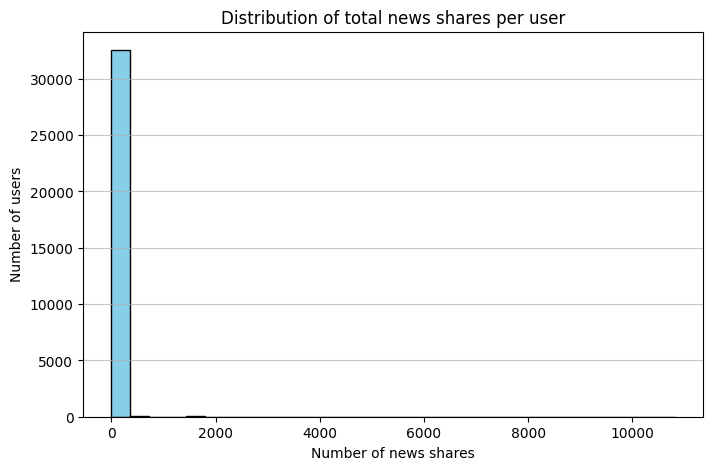

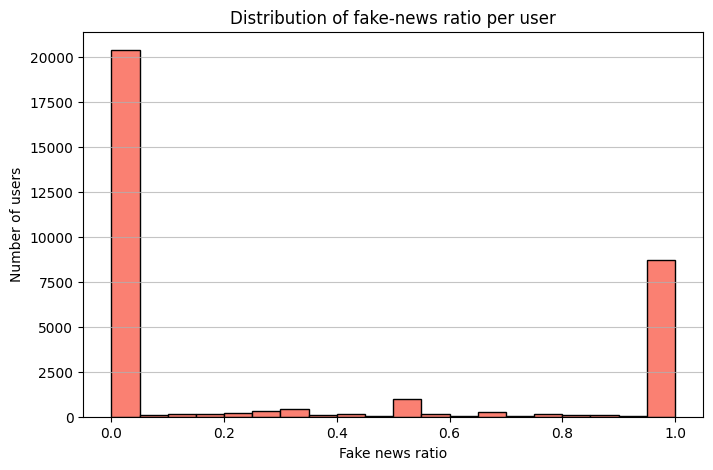

In [5]:
# --- 1) Histogram: number of shares per user ---
plt.figure(figsize=(8,5))
plt.hist(df_users["total"], bins=30, color="skyblue", edgecolor="black")
plt.title("Distribution of total news shares per user")
plt.xlabel("Number of news shares")
plt.ylabel("Number of users")
plt.grid(axis="y", alpha=0.75)
plt.show()

# --- 2) Histogram: ratio of fake news per user ---
# ignore NaNs (users with total=0)
plt.figure(figsize=(8,5))
plt.hist(df_users["fake_ratio"].dropna(), bins=20, color="salmon", edgecolor="black")
plt.title("Distribution of fake-news ratio per user")
plt.xlabel("Fake news ratio")
plt.ylabel("Number of users")
plt.grid(axis="y", alpha=0.75)
plt.show()


As mentioned before often users only have a single retweet and often either or, with a majority sharing real news

In [6]:
df_users.to_csv("df_users_gossip.csv")

df_users

,twitter_id,fake_count,true_count,total,fake_ratio
0,199874723,1607,50,1657,0.969825
1,2471499625,3343,63,3406,0.981503
2,785523426119213056,62,0,62,1.000000
3,2530389144,10653,164,10817,0.984839
4,3157125579,642,11,653,0.983155
...,...,...,...,...,...
32665,1950418886,0,1,1,0.000000
32666,932779158152843264,0,1,1,0.000000
32667,1658330929,0,1,1,0.000000
32668,838196664,0,1,1,0.000000


In [10]:
def sample_profile_features(npz_path, n_samples=5, random_state=42):
    """
    Load the profile feature npz and print sampled rows with column names.
    """
    # Column names based on hand_feature
    col_names = [
        "verified", "geo_enabled", "followers_count", "friends_count",
        "statuses_count", "favourites_count", "listed_count",
        "months_since_twitter_launch", "words_in_name", "words_in_description"
    ]

    # Load sparse matrix
    X = sp.load_npz(npz_path)

    # Convert first n_samples to dense
    X_dense = X.toarray()

    # Sample rows
    rng = np.random.default_rng(seed=random_state)
    idx = rng.choice(X_dense.shape[0], size=min(n_samples, X_dense.shape[0]), replace=False)
    sample_rows = X_dense[idx, :]

    # Print nicely
    for i, row in zip(idx, sample_rows):
        print(f"User index: {i}")
        for name, value in zip(col_names, row):
            print(f"  {name}: {value}")
        print("-" * 30)


print("These are scaled [0:1]")
sample_profile_features(profile_npz, n_samples=3)

These are scaled [0:1]
User index: 205706
  verified: 0.0
  geo_enabled: 0.0
  followers_count: 1.3934641174273565e-07
  friends_count: 1.058186512636894e-06
  statuses_count: 0.005334544461220503
  favourites_count: 0.0
  listed_count: 0.0
  months_since_twitter_launch: 0.8561643958091736
  words_in_name: 0.1111111119389534
  words_in_description: 0.0
------------------------------
User index: 28048
  verified: 0.0
  geo_enabled: 0.0
  followers_count: 0.0001571827451698482
  friends_count: 0.0057734656147658825
  statuses_count: 0.0022117521148175
  favourites_count: 0.0
  listed_count: 0.0005313099245540798
  months_since_twitter_launch: 0.43150684237480164
  words_in_name: 0.1111111119389534
  words_in_description: 0.05882352963089943
------------------------------
User index: 243224
  verified: 0.0
  geo_enabled: 1.0
  followers_count: 0.004258426371961832
  friends_count: 0.007678201422095299
  statuses_count: 0.17190182209014893
  favourites_count: 0.09453120827674866
  listed_c